# Libraries

In [489]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata #Contour plots
from matplotlib import rcParams

# Set global font to Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']

In [490]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240430 - Ag60 GDE_0.9 M Na2SO4_pH2

11-Aug-26  07:29 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
10-Aug-26  06:30 PM    <DIR>          .ipynb_checkpoints
02-May-24  10:29 AM            77,896 0p9M_pH2 Na2SO4_20240502_0829_1min - Copy.xlsx
10-Aug-26  03:55 PM           105,456 0p9M_pH2 Na2SO4_20240502_0829_1min.xlsx
02-May-24  10:29 AM           613,118 0p9M_pH2 Na2SO4_20240502_0829_Line_1.csv
18-Jun-24  02:47 PM           755,772 20240430 - Ag60 GDE_0.9 M Na2SO4_pH2.ipynb
11-Aug-26  07:29 AM           752,815 20240430 - Ag60 GDE_0.9 M Na2SO4_pH2-CORRECTED.ipynb
10-Aug-26  07:38 PM               579 20240430_0.9 M Na2SO4_pH2_Energy Consumption.csv
11-Aug-26  07:28 AM             5,570 20240430_0.9M Na2SO4_pH2.csv
10-Aug-26  07:38 PM             1,410 20240430_0.9M Na2SO4_pH2_flow rate.csv
18-Jun-24  02:47 PM           150,946 

# Load Data

In [491]:
Book = "Book_20240430 - Ag60 GDE_0.9 M Na2SO4_pH2.xlsx"
Book = pd.read_excel(Book)
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(H2),c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24
0,Ag60 GDE in PTFE holder,60,51.4,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:37:00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN
1,Ag60 GDE in PTFE holder,60,54.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:55:00,0.300000,1.463835,...,0.014221,0.001287,0.978646,0.001775,0.951658,0.086135,NaN,1.037792,0.001314,NaN
2,Ag60 GDE in PTFE holder,60,56.4,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 12:29:00,0.866667,1.502916,...,0.014628,0.002370,0.981858,0.001123,1.020515,0.165350,NaN,1.185866,0.002408,101.120405
3,Ag60 GDE in PTFE holder,60,58.2,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 13:21:00,1.733333,1.306571,...,0.012713,0.003748,0.982740,0.000783,0.915216,0.269792,NaN,1.185008,0.003799,NaN
4,Ag60 GDE in PTFE holder,60,58.7,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.250,2024-04-30 14:21:00,2.733333,0.669595,...,0.006514,0.028551,0.964334,0.000582,0.202419,0.887272,NaN,1.089690,0.028756,102.068493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,Ag60 GDE in PTFE holder,60,61.9,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.000,2024-05-02 07:49:00,44.200000,3.218692,...,0.031446,0.028119,0.938864,0.000432,0.085875,0.076790,NaN,0.162665,0.029079,NaN
120,Ag60 GDE in PTFE holder,60,61.7,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.000,2024-05-02 08:06:00,44.483333,3.231061,...,0.031583,0.028040,0.938696,0.000459,0.085969,0.076327,NaN,0.162297,0.029005,98.902233
121,Ag60 GDE in PTFE holder,60,61.9,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.000,2024-05-02 08:23:00,44.766667,3.237169,...,0.031650,0.027924,0.939964,0.000448,0.086432,0.076256,NaN,0.162687,0.028850,NaN
122,Ag60 GDE in PTFE holder,60,62.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.000,2024-05-02 08:40:00,45.050000,3.244529,...,0.031667,0.027877,0.938875,0.000437,0.086757,0.076374,NaN,0.163131,0.028835,99.052203


In [492]:
Book["Duration / h"] = round(Book["Duration / h"],2)
Book["Flow rate (ml min-1)"] = round(Book["Flow rate (ml min-1)"],2)
# Flow_df = Book[["Time", "Duration / h", "Flow rate (ml min-1)"]].copy()
Book["GC_flow_rate_ml_min"] = Book["Flow rate (ml min-1)"]
Book.tail(3)

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO),c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min
121,Ag60 GDE in PTFE holder,60,61.9,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.0,2024-05-02 08:23:00,44.77,3.237169,...,0.027924,0.939964,0.000448,0.086432,0.076256,NaN,0.162687,0.028850,NaN,61.9
122,Ag60 GDE in PTFE holder,60,62.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.0,2024-05-02 08:40:00,45.05,3.244529,...,0.027877,0.938875,0.000437,0.086757,0.076374,NaN,0.163131,0.028835,99.052203,62.1
123,Ag60 GDE in PTFE holder,60,62.4,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-3.0,2024-05-02 09:14:00,45.62,3.267116,...,0.027621,0.938793,0.000452,0.087875,0.076038,NaN,0.163914,0.028581,NaN,62.4


### Temp from pH meter

In [493]:
Temp = "2024-04-30_162454.csv"
Temp = pd.read_csv(Temp)
Temp[["Supp Reading 1", "Supp Units 1"]]
Temp_C_mean = Temp["Supp Reading 1"].mean()
Temp_C_median = Temp["Supp Reading 1"].median()

print("Temp C mean:", Temp_C_mean)
print("Temp C median:", Temp_C_median)

Temp C mean: 23.9596463022508
Temp C median: 24.0


## Power supply

In [494]:
power_sup = "Power supply_1.csv"
power_sup = pd.read_csv(power_sup, sep=";")
power_sup.head(2)

,U set,U actual,I set,I actual,P set,P actual,R set,R actual,R mode,Output/Input,Device mode,Error,Time
0,0.00V,0.17V,0.000A,0.000A,320.00W,0.00W,NaN,NaN,NaN,On,CV,NaN,30.04.2024 11:37:51.450
1,40.00V,2.61V,0.100A,0.101A,320.00W,0.00W,NaN,NaN,NaN,On,CC,NaN,30.04.2024 11:37:56.456


In [495]:
power_sup.groupby("I set", group_keys=True)[['U actual']].apply(lambda x: x).head(3)

U actual
I set            
0.000A 0    0.17V
0.100A 1    2.61V
       2    2.82V

In [496]:
power_sup["Time"] = pd.to_datetime(
    power_sup["Time"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

power_sup["I actual"] = (
    power_sup["I actual"]
    .str.replace("A", "", regex=False)
    .str.strip()
    .astype(float)
)
power_sup["U actual"] = (
    power_sup["U actual"]
    .str.replace("V", "", regex=False)
    .str.strip()
    .astype(float)
)

# Set time as index
power_sup = power_sup.set_index("Time")

# Mean current and voltage every 2 hours
power_summary = (
    power_sup.resample("2h")
    .agg({
        "I actual": "max",
        "U actual": "max"
    })
    .reset_index()
)

# Rename column
# I_mean = I_mean.rename(columns={"I actual": "I actual_mean (A)"})
print(power_summary)

                  Time  I actual  U actual
0  2024-04-30 10:00:00     0.107      2.98
1  2024-04-30 12:00:00     0.262      3.70
2  2024-04-30 14:00:00     0.507      4.58
3  2024-04-30 16:00:00     0.754      5.29
4  2024-04-30 18:00:00     1.003      5.91
5  2024-04-30 20:00:00     1.504      6.67
6  2024-04-30 22:00:00     1.991      7.41
7  2024-05-01 00:00:00     2.997      8.81
8  2024-05-01 02:00:00     2.998      8.93
9  2024-05-01 04:00:00     0.508      4.35
10 2024-05-01 06:00:00     0.507      4.37
11 2024-05-01 08:00:00     0.506      4.36
12 2024-05-01 10:00:00     0.506      4.39
13 2024-05-01 12:00:00     0.507      4.39
14 2024-05-01 14:00:00     0.505      4.39
15 2024-05-01 16:00:00     0.507      4.43
16 2024-05-01 18:00:00     0.509      4.43
17 2024-05-01 20:00:00     0.507      4.44
18 2024-05-01 22:00:00     0.507      4.44
19 2024-05-02 00:00:00     0.508      4.43
20 2024-05-02 02:00:00     0.507      4.43
21 2024-05-02 04:00:00     0.507      4.41
22 2024-05-

In [497]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
power_summary = power_summary.iloc[:-16].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-04-30 10:00:00     0.107      2.98
1 2024-04-30 12:00:00     0.262      3.70
2 2024-04-30 14:00:00     0.507      4.58
3 2024-04-30 16:00:00     0.754      5.29
4 2024-04-30 18:00:00     1.003      5.91
5 2024-04-30 20:00:00     1.504      6.67
6 2024-04-30 22:00:00     1.991      7.41
7 2024-05-01 00:00:00     2.997      8.81


In [498]:
# power_summary = power_summary.iloc[3:].reset_index(drop=True) #Power supply was recording before the experiment
# power_summary.loc[power_summary.index[0], "I actual"] = 0 #The first row will be taken is 0, not current was input
# power_summary = power_summary.iloc[:-1].reset_index(drop=True) #after 16h
print(power_summary)

                 Time  I actual  U actual
0 2024-04-30 10:00:00     0.107      2.98
1 2024-04-30 12:00:00     0.262      3.70
2 2024-04-30 14:00:00     0.507      4.58
3 2024-04-30 16:00:00     0.754      5.29
4 2024-04-30 18:00:00     1.003      5.91
5 2024-04-30 20:00:00     1.504      6.67
6 2024-04-30 22:00:00     1.991      7.41
7 2024-05-01 00:00:00     2.997      8.81


In [499]:
dfcell_voltage = pd.DataFrame(power_summary)
dfcell_voltage = dfcell_voltage.rename(columns={"U actual": "Voltage"})
dfcell_voltage = dfcell_voltage.set_index("I actual")
dfcell_voltage = dfcell_voltage.drop(columns=["Time"])
dfcell_voltage

,Voltage
I actual,
0.107,2.98
0.262,3.70
0.507,4.58
0.754,5.29
1.003,5.91
1.504,6.67
1.991,7.41
2.997,8.81


In [500]:
dfcell_voltage["Current Density [mA cm-2]"] = dfcell_voltage.index*10
dfcell_voltage

,Voltage,Current Density [mA cm-2]
I actual,,
0.107,2.98,1.07
0.262,3.70,2.62
0.507,4.58,5.07
0.754,5.29,7.54
1.003,5.91,10.03
1.504,6.67,15.04
1.991,7.41,19.91
2.997,8.81,29.97


### Flow rate

In [501]:
flow_rate = "0p9M_pH2 Na2SO4_20240502_0829_1min.xlsx"
flow_rate = pd.read_excel(flow_rate, sheet_name="Process data")
flow_rate.head(25)

,Unnamed: 0,Unnamed: 1,Unnamed: 2
0,Report generated (UTC),2024-05-02 08:29:15.101000,NaN
1,Software version,Aurora 1.0.2,NaN
2,Instrument name,0p9M_pH2 Na2SO4,NaN
3,Instrument model name,BPC Go,NaN
4,Ethernet mac address,f8:dc:7a:6e:f2:c4,NaN
5,Agitation state,Off,NaN
6,Agitation phase,Single,NaN
7,Agitation phase speed (%),30,NaN
8,Gas normalisation,Unnormalised,NaN
9,NaN,NaN,NaN


In [502]:
flow_rate = flow_rate.iloc[18:].reset_index(drop=True)
flow_rate = flow_rate.rename(columns={
    "Unnamed: 0": "Time (UTC)",
    "Unnamed: 1": "Gas flow rate [ml/min]",
    "Unnamed: 2": "Specific gas production [ml/min/l]"
})

flow_rate

,Time (UTC),Gas flow rate [ml/min],Specific gas production [ml/min/l]
0,2024-04-30 09:36:59.962000,51.381031,25.690516
1,2024-04-30 09:38:00.010000,51.373905,25.686952
2,2024-04-30 09:38:59.971000,52.428398,26.214199
3,2024-04-30 09:40:00.019000,52.900603,26.450301
4,2024-04-30 09:40:59.981000,52.945866,26.472933
...,...,...,...
2808,2024-05-02 08:24:59.962000,61.458565,30.729282
2809,2024-05-02 08:26:00.010000,60.913382,30.456691
2810,2024-05-02 08:26:59.971000,61.142774,30.571387
2811,2024-05-02 08:28:00.019000,61.581966,30.790983


In [503]:
flow_rate["Time (UTC)"] = pd.to_datetime(
    flow_rate["Time (UTC)"],
    format="%d.%m.%Y %H:%M:%S.%f"
)

# Set time as index
flow_rate = flow_rate.set_index("Time (UTC)")

# Mean current and voltage every 2 hours
flow_rate = (
    flow_rate.resample("2h")
    .agg(Flow_rate_min=("Gas flow rate [ml/min]", "min"), 
         Flow_rate_max=("Gas flow rate [ml/min]", "max"),
         Flow_rate_mean=("Gas flow rate [ml/min]", "mean"),
         Flow_rate_median=("Gas flow rate [ml/min]", "median"))
    .reset_index()
)

print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2024-04-30 08:00:00     51.373905     54.474215      53.341356   
1  2024-04-30 10:00:00     54.259259      58.81202      57.138952   
2  2024-04-30 12:00:00     57.977632     59.510189      58.884031   
3  2024-04-30 14:00:00     58.661996     59.676617        59.1283   
4  2024-04-30 16:00:00     58.931263      60.63899      59.624296   
5  2024-04-30 18:00:00     59.674297     63.474981      60.700131   
6  2024-04-30 20:00:00     62.797099      67.25441      63.930387   
7  2024-04-30 22:00:00      66.39776     76.279158       68.38976   
8  2024-05-01 00:00:00     56.043266     75.467352      71.589487   
9  2024-05-01 02:00:00      57.24859     60.655351      59.290167   
10 2024-05-01 04:00:00     59.969153     61.565814      60.615418   
11 2024-05-01 06:00:00     60.353439     62.044783      61.165508   
12 2024-05-01 08:00:00     60.829814     62.624808      61.814374   
13 2024-05-01 10:00:00     60.7285

#### Correction dry flow

In [504]:
# ---- physical constants ---- For FE% later
F   = 96485        # Faraday constant                   [C/mol]
R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
T   = Temp_C_median + 273.15     # gas temperature at the meter       [K]  (~23.3 degC)
P   = 101325       # pressure                           [Pa]
V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- wet-to-dry correction ----
# The flow meter reads the wet gas leaving the cell. Assuming saturation at the
# meter temperature, water occupies x_H2O of the stream; the remaining fraction
# is product + carrier. p_sat from the Buck equation.
T_C   = Temp_C_median
P_SAT = 0.61121*np.exp((18.678 - T_C/234.5)*(T_C/(257.14 + T_C))) * 1000   # Pa
X_H2O = P_SAT / P                  # 0.0282 at 23.3 degC
DRY   = 1 - X_H2O                  # 0.9718

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]

print(f"V_m   = {V_m:.3f} L/mol")
print(f"p_sat = {P_SAT/1000:.4f} kPa -> x(H2O) = {X_H2O*100:.2f} % -> dry factor {DRY:.5f}")

V_m   = 24.382 L/mol
p_sat = 2.9845 kPa -> x(H2O) = 2.95 % -> dry factor 0.97055


In [505]:
FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]
for c in FLOW_COLS:
    flow_rate[c + "_dry"] = flow_rate[c] * DRY

# FLOW_COLS = ["Flow_rate_min", "Flow_rate_max", "Flow_rate_mean", "Flow_rate_median"]

# for c in FLOW_COLS:
#     flow_rate[c + "_corr"] = flow_rate[c] * 0.9723

# flow_rate

In [506]:
print(flow_rate)

            Time (UTC) Flow_rate_min Flow_rate_max Flow_rate_mean  \
0  2024-04-30 08:00:00     51.373905     54.474215      53.341356   
1  2024-04-30 10:00:00     54.259259      58.81202      57.138952   
2  2024-04-30 12:00:00     57.977632     59.510189      58.884031   
3  2024-04-30 14:00:00     58.661996     59.676617        59.1283   
4  2024-04-30 16:00:00     58.931263      60.63899      59.624296   
5  2024-04-30 18:00:00     59.674297     63.474981      60.700131   
6  2024-04-30 20:00:00     62.797099      67.25441      63.930387   
7  2024-04-30 22:00:00      66.39776     76.279158       68.38976   
8  2024-05-01 00:00:00     56.043266     75.467352      71.589487   
9  2024-05-01 02:00:00      57.24859     60.655351      59.290167   
10 2024-05-01 04:00:00     59.969153     61.565814      60.615418   
11 2024-05-01 06:00:00     60.353439     62.044783      61.165508   
12 2024-05-01 08:00:00     60.829814     62.624808      61.814374   
13 2024-05-01 10:00:00     60.7285

In [507]:
dfflow_rate = pd.DataFrame(flow_rate)
dfflow_rate['Current [A]'] = power_summary['I actual']
dfflow_rate['Voltage'] = power_summary['U actual']
dfflow_rate = dfflow_rate.iloc[:-17].reset_index(drop=True)
# dfflow_rate = dfflow_rate*0.9723
dfflow_rate

,Time (UTC),Flow_rate_min,Flow_rate_max,Flow_rate_mean,Flow_rate_median,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_mean_dry,Flow_rate_median_dry,Current [A],Voltage
0,2024-04-30 08:00:00,51.373905,54.474215,53.341356,53.423339,49.860707,52.869699,51.770208,51.849776,0.107,2.98
1,2024-04-30 10:00:00,54.259259,58.81202,57.138952,57.560856,52.661074,57.079735,55.455947,55.865424,0.262,3.70
2,2024-04-30 12:00:00,57.977632,59.510189,58.884031,58.847617,56.269924,57.75734,57.149625,57.114284,0.507,4.58
3,2024-04-30 14:00:00,58.661996,59.676617,59.1283,59.101318,56.93413,57.918866,57.3867,57.360512,0.754,5.29
4,2024-04-30 16:00:00,58.931263,60.63899,59.624296,59.574702,57.195466,58.852893,57.868086,57.819952,1.003,5.91
5,2024-04-30 18:00:00,59.674297,63.474981,60.700131,60.186105,57.916614,61.605351,58.912233,58.413347,1.504,6.67
6,2024-04-30 20:00:00,62.797099,67.25441,63.930387,63.363174,60.947435,65.273458,62.047343,61.496837,1.991,7.41
7,2024-04-30 22:00:00,66.39776,76.279158,68.38976,66.85631,64.44204,74.032386,66.375367,64.887084,2.997,8.81


In [510]:
# dfflow_rate.to_csv('20240430_0.9M Na2SO4_pH2_flow rate.csv')

# Energy consumption

Units: cm2 to m2: 1000cm2 is 1m2.  <br>
mA to A: 1000mA is 1A.  <br>
hrs to sec: 1hr is 3600 <br>
10cm2 = 0.001m2. <br> 2hr = 7200 <br>
1Wh = 3600J <br>

*Energy consumption* = Current density [A cm2]* time [s] * cell voltage [V] * area of the electrode [m2]

In [511]:
electrode_area = 10/10000 #10cm2 to m2
time = 2*3600 #2hrs

dfcell_voltage["Current Density [A m-2]"] = dfcell_voltage["Current Density [mA cm-2]"]*100000/1000
dfcell_voltage.head(3)

,Voltage,Current Density [mA cm-2],Current Density [A m-2]
I actual,,,
0.107,2.98,1.07,107.0
0.262,3.70,2.62,262.0
0.507,4.58,5.07,507.0


In [512]:
dfcell_voltage["Energy Consumption [J]"] = dfcell_voltage.index * time * dfcell_voltage["Voltage"]
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J]
I actual,,,,
0.107,2.98,1.07,107.0,2295.792
0.262,3.70,2.62,262.0,6979.680
0.507,4.58,5.07,507.0,16718.832
0.754,5.29,7.54,754.0,28718.352
1.003,5.91,10.03,1003.0,42679.656
1.504,6.67,15.04,1504.0,72228.096
1.991,7.41,19.91,1991.0,106223.832
2.997,8.81,29.97,2997.0,190105.704


In [513]:
dfcell_voltage["Energy Consumption [kWh]"] = dfcell_voltage["Energy Consumption [J]"]/3600000 #1kWh is 3.6xe6 joules
dfcell_voltage

,Voltage,Current Density [mA cm-2],Current Density [A m-2],Energy Consumption [J],Energy Consumption [kWh]
I actual,,,,,
0.107,2.98,1.07,107.0,2295.792,0.000638
0.262,3.70,2.62,262.0,6979.680,0.001939
0.507,4.58,5.07,507.0,16718.832,0.004644
0.754,5.29,7.54,754.0,28718.352,0.007977
1.003,5.91,10.03,1003.0,42679.656,0.011855
1.504,6.67,15.04,1504.0,72228.096,0.020063
1.991,7.41,19.91,1991.0,106223.832,0.029507
2.997,8.81,29.97,2997.0,190105.704,0.052807


In [516]:
# dfcell_voltage.to_csv('20240430_0.9 M Na2SO4_pH2_Energy Consumption.csv')

## Integer Duration ("Applied Current /A" - Values optimization)

In [517]:
Book['Integer Duration'] = np.floor(Book['Duration / h'])
Book = Book[Book['Integer Duration'] < 16].copy()
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(CO2),c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration
0,Ag60 GDE in PTFE holder,60,51.4,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:37:00,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,51.4,0.0
1,Ag60 GDE in PTFE holder,60,54.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:55:00,0.30,1.463835,...,0.978646,0.001775,0.951658,0.086135,NaN,1.037792,0.001314,NaN,54.1,0.0
2,Ag60 GDE in PTFE holder,60,56.4,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 12:29:00,0.87,1.502916,...,0.981858,0.001123,1.020515,0.165350,NaN,1.185866,0.002408,101.120405,56.4,0.0
3,Ag60 GDE in PTFE holder,60,58.2,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 13:21:00,1.73,1.306571,...,0.982740,0.000783,0.915216,0.269792,NaN,1.185008,0.003799,NaN,58.2,1.0
4,Ag60 GDE in PTFE holder,60,58.7,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.250,2024-04-30 14:21:00,2.73,0.669595,...,0.964334,0.000582,0.202419,0.887272,NaN,1.089690,0.028756,102.068493,58.7,2.0
5,Ag60 GDE in PTFE holder,60,59.5,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.250,2024-04-30 15:22:00,3.75,0.789326,...,0.964553,0.000504,0.242228,0.857838,NaN,1.100066,0.027459,NaN,59.5,3.0
6,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-30 15:56:00,4.32,0.689069,...,0.939759,0.000492,0.100816,0.800755,NaN,0.901570,0.053438,102.420199,59.3,4.0
7,Ag60 GDE in PTFE holder,60,59.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-30 16:30:00,4.88,0.742768,...,0.937045,0.000482,0.108320,0.831193,NaN,0.939514,0.055685,NaN,59.1,4.0
8,Ag60 GDE in PTFE holder,60,58.8,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-30 17:05:00,5.47,0.779967,...,0.937055,0.000481,0.113263,0.821311,NaN,0.934574,0.055325,102.229682,58.8,5.0
9,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.760,2024-04-30 17:57:00,6.33,1.427604,...,0.912500,0.000462,0.142684,0.755401,NaN,0.898085,0.074213,NaN,59.3,6.0


## Current Density

In [518]:
Book["Current Density"] = (Book['Applied current / A']/10)*1000 #mA
Book

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,c(O2),FE(H2),FE(CO),FE(CH4),Total FE,Carbon efficiency,Unnamed: 24,GC_flow_rate_ml_min,Integer Duration,Current Density
0,Ag60 GDE in PTFE holder,60,51.4,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:37:00,0.00,0.000000,...,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,51.4,0.0,-10.7
1,Ag60 GDE in PTFE holder,60,54.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:55:00,0.30,1.463835,...,0.001775,0.951658,0.086135,NaN,1.037792,0.001314,NaN,54.1,0.0,-10.7
2,Ag60 GDE in PTFE holder,60,56.4,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 12:29:00,0.87,1.502916,...,0.001123,1.020515,0.165350,NaN,1.185866,0.002408,101.120405,56.4,0.0,-10.7
3,Ag60 GDE in PTFE holder,60,58.2,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 13:21:00,1.73,1.306571,...,0.000783,0.915216,0.269792,NaN,1.185008,0.003799,NaN,58.2,1.0,-10.7
4,Ag60 GDE in PTFE holder,60,58.7,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.250,2024-04-30 14:21:00,2.73,0.669595,...,0.000582,0.202419,0.887272,NaN,1.089690,0.028756,102.068493,58.7,2.0,-25.0
5,Ag60 GDE in PTFE holder,60,59.5,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.250,2024-04-30 15:22:00,3.75,0.789326,...,0.000504,0.242228,0.857838,NaN,1.100066,0.027459,NaN,59.5,3.0,-25.0
6,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-30 15:56:00,4.32,0.689069,...,0.000492,0.100816,0.800755,NaN,0.901570,0.053438,102.420199,59.3,4.0,-52.0
7,Ag60 GDE in PTFE holder,60,59.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-30 16:30:00,4.88,0.742768,...,0.000482,0.108320,0.831193,NaN,0.939514,0.055685,NaN,59.1,4.0,-52.0
8,Ag60 GDE in PTFE holder,60,58.8,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.520,2024-04-30 17:05:00,5.47,0.779967,...,0.000481,0.113263,0.821311,NaN,0.934574,0.055325,102.229682,58.8,5.0,-52.0
9,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.760,2024-04-30 17:57:00,6.33,1.427604,...,0.000462,0.142684,0.755401,NaN,0.898085,0.074213,NaN,59.3,6.0,-76.0


## FE(CO)

In [519]:
# Book["FE(CO)"] = Book["c(CO)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [520]:
# # ---- physical constants ----
# F   = 96485        # Faraday constant                   [C/mol]
# R   = 8.314        # ideal-gas constant                 [J/(mol*K)]
# T   = 296.45       # gas temperature at the meter       [K]  (~23.3 degC)
# P   = 101325       # pressure                           [Pa]
# V_m = (R*T/P)*1000 # molar volume of an ideal gas       [L/mol]  -> the "24.3"

# ---- reaction / cell parameters ----
n_e   = 2          # electrons per molecule:  H2 (2 H+ + 2 e- -> H2)
                   #                          CO (CO2 + 2 H+ + 2 e- -> CO + H2O)
A_cm2 = 10         # geometric electrode area           [cm^2]
print(f"V_m = {V_m:.3f} L/mol")

V_m = 24.382 L/mol


In [521]:
currents     = [i for i in dfcell_voltage.index.to_list() if i != 0]
currents

[0.107, 0.262, 0.507, 0.754, 1.003, 1.504, 1.991, 2.997]

In [522]:
# Determine the 2 h step for each GC injection
step = (Book["Duration / h"] // 2).astype(int)

# Count injections per step
inj_per_step = step.value_counts().sort_index().tolist()
inj_per_step

[4, 2, 3, 2, 5, 4, 5, 4]

In [523]:
currents # The actual applied current from the power supply file (without the first 0)   # GC injections per step (estimate). From Book excel
inj_per_step # GC injections per step (2h)

I_seq = np.repeat(currents, inj_per_step)
# rows  = Book.iloc[first_row : first_row + len(I_seq)].copy().reset_index(drop=True)
rows = Book.iloc[:len(I_seq)].copy().reset_index(drop=True)
rows["Current_abs"] = rows["Applied current / A"].abs()

rows = rows.sort_values("Current_abs")
dfflow_rate = dfflow_rate.sort_values("Current [A]")

rows = pd.merge_asof(
    rows,
    dfflow_rate[["Current [A]", "Flow_rate_mean_dry", "Flow_rate_min_dry", "Flow_rate_max_dry", "Flow_rate_median_dry"]],
    left_on="Current_abs",
    right_on="Current [A]",
    direction="nearest"
)
# Clean columns
# rows = rows.drop(columns=["Current_abs", "Current [A]"])

rows["Applied current / A"] = -I_seq                    # cathodic -> negative
rows["Current Density"]     = rows["Applied current / A"] / 10 * 10000   # mA cm-2 10 is A_cm2 electrode

# check: c(H2) should rise monotonically from one step to the next
print(rows.groupby(rows["Applied current / A"].abs())[["c(H2)", "c(CO)"]].median().round(3))

                     c(H2)  c(CO)
Applied current / A              
0.107                0.013  0.002
0.262                0.007  0.028
0.507                0.007  0.055
0.754                0.016  0.072
1.003                0.028  0.082
1.504                0.072  0.084
1.991                0.118  0.083
2.997                0.203  0.074


In [524]:
def faradaic_efficiency(conc, flow_ml_min, current_A, n_electrons):
    gas_volume_ml_min = conc * flow_ml_min #Concentration in molar_fraction × flow_total = vol gas
    gas_volume_L_s = gas_volume_ml_min / 1000 / 60 #ml/min → L/s
    mol_per_s = gas_volume_L_s / V_m #volume → molar flow using V_m (Ideal gas law)
    charge_rate = mol_per_s * n_electrons * F # moles to amp. Each molecule carries z electrons
    FE = (charge_rate / abs(current_A)) * 100
    return FE

rows["FE(CO)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(CO)"], 
        row["Flow_rate_median_dry"],    # 2h period
        row["Current [A]"], 
        2
    ), 
    axis=1
)

rows["FE(H2)"] = rows.apply(
    lambda row: faradaic_efficiency(
        row["c(H2)"], 
        row["Flow_rate_median_dry"], 
        row["Current [A]"], 
        2
    ), 
    axis=1
)

# rows.loc[rows.index[0], "FE(H2)"] = 0
rows["FE(total)"] = rows["FE(H2)"] + rows["FE(CO)"]

# rows[["Current Density", "FE(H2)", "FE(CO)", "FE(total)"]].head(15)

# sanity check: H2 + CO must stay around / below 100 %
_tot = rows["FE(H2)"] + rows["FE(CO)"]
print(f"FE_total  min/max/mean = {_tot.min():.1f} / {_tot.max():.1f} / {_tot.mean():.1f} %")

FE_total  min/max/mean = 0.0 / 108.7 / 82.4 %


In [527]:
rows = rows.drop(rows[rows['FE(total)'] > 105].index) #Noise in the first measurements
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
0,Ag60 GDE in PTFE holder,60,51.4,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:37:00,0.00,0.000000,...,51.4,0.0,-107.0,0.107,0.107,51.770208,49.860707,52.869699,51.849776,0.000000
1,Ag60 GDE in PTFE holder,60,54.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:55:00,0.30,1.463835,...,54.1,0.0,-107.0,0.107,0.107,51.770208,49.860707,52.869699,51.849776,99.128209
4,Ag60 GDE in PTFE holder,60,58.7,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.262,2024-04-30 14:21:00,2.73,0.669595,...,58.7,2.0,-262.0,0.250,0.262,55.455947,52.661074,57.079735,55.865424,98.624299
5,Ag60 GDE in PTFE holder,60,59.5,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.262,2024-04-30 15:22:00,3.75,0.789326,...,59.5,3.0,-262.0,0.250,0.262,55.455947,52.661074,57.079735,55.865424,98.224714
6,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 15:56:00,4.32,0.689069,...,59.3,4.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,88.761010
7,Ag60 GDE in PTFE holder,60,59.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 16:30:00,4.88,0.742768,...,59.1,4.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,92.809610
8,Ag60 GDE in PTFE holder,60,58.8,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 17:05:00,5.47,0.779967,...,58.8,5.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,92.792664
9,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.754,2024-04-30 17:57:00,6.33,1.427604,...,59.3,6.0,-754.0,0.760,0.754,57.3867,56.93413,57.918866,57.360512,87.268020
10,Ag60 GDE in PTFE holder,60,59.6,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.754,2024-04-30 18:49:00,7.20,1.776337,...,59.6,7.0,-754.0,0.760,0.754,57.3867,56.93413,57.918866,57.360512,88.182106
11,Ag60 GDE in PTFE holder,60,59.8,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-1.003,2024-04-30 21:31:00,9.90,3.049153,...,59.8,9.0,-1003.0,1.100,1.003,57.868086,57.195466,58.852893,57.819952,84.350257


In [528]:
rows[rows["FE(total)"]>100 ]

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)


In [529]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.07].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,54.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:55:00,0.30,1.463835,...,54.1,0.0,-107.0,0.107,0.107,51.770208,49.860707,52.869699,51.849776,99.128209
4,Ag60 GDE in PTFE holder,60,58.7,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.262,2024-04-30 14:21:00,2.73,0.669595,...,58.7,2.0,-262.0,0.250,0.262,55.455947,52.661074,57.079735,55.865424,98.624299
5,Ag60 GDE in PTFE holder,60,59.5,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.262,2024-04-30 15:22:00,3.75,0.789326,...,59.5,3.0,-262.0,0.250,0.262,55.455947,52.661074,57.079735,55.865424,98.224714
6,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 15:56:00,4.32,0.689069,...,59.3,4.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,88.761010
7,Ag60 GDE in PTFE holder,60,59.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 16:30:00,4.88,0.742768,...,59.1,4.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,92.809610
8,Ag60 GDE in PTFE holder,60,58.8,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 17:05:00,5.47,0.779967,...,58.8,5.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,92.792664
9,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.754,2024-04-30 17:57:00,6.33,1.427604,...,59.3,6.0,-754.0,0.760,0.754,57.3867,56.93413,57.918866,57.360512,87.268020
10,Ag60 GDE in PTFE holder,60,59.6,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.754,2024-04-30 18:49:00,7.20,1.776337,...,59.6,7.0,-754.0,0.760,0.754,57.3867,56.93413,57.918866,57.360512,88.182106
11,Ag60 GDE in PTFE holder,60,59.8,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-1.003,2024-04-30 21:31:00,9.90,3.049153,...,59.8,9.0,-1003.0,1.100,1.003,57.868086,57.195466,58.852893,57.819952,84.350257
12,Ag60 GDE in PTFE holder,60,60.0,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-1.003,2024-04-30 20:40:00,9.05,2.921810,...,60.0,9.0,-1003.0,1.100,1.003,57.868086,57.195466,58.852893,57.819952,84.354522


## Mean FE per current density

In [530]:
summary = (
    rows.groupby(rows["Current Density"].abs().round(3).astype(int))
    .agg(
        # Faradaic efficiencies
        FE_H2_mean=("FE(H2)", "mean"),
        FE_CO_mean=("FE(CO)", "mean"),
        FE_H2_median=("FE(H2)", "median"),
        FE_CO_median=("FE(CO)", "median"),

        FE_H2_sem=("FE(H2)", "sem"),
        FE_CO_sem=("FE(CO)", "sem"),
        FE_H2_std=("FE(H2)", "std"),
        FE_CO_std=("FE(CO)", "std"),

        # IQR values for H2 and CO (median error bars)
        FE_H2_q25=("FE(H2)", lambda x: x.quantile(0.25)),
        FE_H2_q75=("FE(H2)", lambda x: x.quantile(0.75)),
        FE_CO_q25=("FE(CO)", lambda x: x.quantile(0.25)),
        FE_CO_q75=("FE(CO)", lambda x: x.quantile(0.75)),

        # Total FE statistics
        FE_total_mean=("FE(total)", "mean"),
        FE_total_median=("FE(total)", "median"),
        FE_total_sem=("FE(total)", "sem"),
        FE_total_std=("FE(total)", "std"),
        FE_total_q25=("FE(total)", lambda x: x.quantile(0.25)),
        FE_total_q75=("FE(total)", lambda x: x.quantile(0.75)),

        # Flow rate
        Flow_rate_min=("Flow rate (ml min-1)", "min"),
        Flow_rate_max=("Flow rate (ml min-1)", "max"),
        Flow_rate_mean=("Flow rate (ml min-1)", "mean"),
        Flow_rate_median=("Flow rate (ml min-1)", "median"),

        # CO concentration
        c_CO_min=("c(CO)", "min"),
        c_CO_max=("c(CO)", "max"),
        c_CO_mean=("c(CO)", "mean"),
        c_CO_median=("c(CO)", "median"),

        # H2 concentration
        c_H2_min=("c(H2)", "min"),
        c_H2_max=("c(H2)", "max"),
        c_H2_mean=("c(H2)", "mean"),
        c_H2_median=("c(H2)", "median"),

        # Number of measurements
        n=("FE(H2)", "size")
    )
    .reset_index()
    .rename(columns={"Current Density": "J (A m-2)"})
)

# Error bars for median (IQR)
summary["FE_H2_err_low"] = (
    summary["FE_H2_median"] - summary["FE_H2_q25"]
)
summary["FE_H2_err_high"] = (
    summary["FE_H2_q75"] - summary["FE_H2_median"]
)

summary["FE_CO_err_low"] = (
    summary["FE_CO_median"] - summary["FE_CO_q25"]
)
summary["FE_CO_err_high"] = (
    summary["FE_CO_q75"] - summary["FE_CO_median"]
)

summary["FE_total_err_low"] = (
    summary["FE_total_median"] - summary["FE_total_q25"]
)
summary["FE_total_err_high"] = (
    summary["FE_total_q75"] - summary["FE_total_median"]
)

# Experimental time intervals
summary["Time Interval (h)"] = [
    "0–2", "2–4", "4–6", "6–8",
    "8–10", "10–12", "12–14", "14–16"
]

print(summary)

   J (A m-2)  FE_H2_mean  FE_CO_mean  FE_H2_median  FE_CO_median  FE_H2_sem  \
0        107   90.900776    8.227432     90.900776      8.227432        NaN   
1        262   19.974374   78.450132     19.974374     78.450132   1.654137   
2        507   10.623867   80.830561     10.700402     81.546922   0.383050   
3        754   15.657252   72.067811     15.657252     72.067811   1.792506   
4       1003   21.886203   62.478351     21.864749     62.601593   0.300298   
5       1504   36.075511   43.369335     36.779185     43.042665   1.154308   
6       1991   44.904743   33.431299     48.132619     33.614692   3.669808   
7       2997   57.781385   21.107219     58.072005     21.076218   0.545567   

   FE_CO_sem  FE_H2_std  FE_CO_std  FE_H2_q25  ...  c_H2_mean  c_H2_median  n  \
0        NaN        NaN        NaN  90.900776  ...   0.014221     0.014221  1   
1   1.853930   2.339303   2.621853  19.147305  ...   0.007102     0.007102  2   
2   1.010624   0.663462   1.750453  10.312929

In [531]:
print(rows["FE(CO)"])

1      8.227432
4     80.304062
5     76.596202
6     78.835552
7     82.109208
8     81.546922
9     73.403274
10    70.732347
11    61.745834
12    62.723591
13    62.479594
15    62.964386
16    44.851333
17    43.350424
18    42.734905
19    42.540677
20    34.178670
21    34.181865
22    33.614692
23    33.206361
24    31.974908
25    20.821916
26    21.454524
27    21.258804
28    20.893631
Name: FE(CO), dtype: float64


## FE(H2)

In [532]:
# Book["FE(H2)"] = Book["c(H2)"]*Book["Flow rate (ml min-1)"]/1000/60/24.3*2*96485/-1/Book["Applied current / A"]

In [533]:
print(rows["FE(H2)"])

1     90.900776
4     18.320237
5     21.628511
6      9.925457
7     10.700402
8     11.245742
9     13.864745
10    17.449758
11    22.604424
12    21.630931
13    22.098567
15    21.210891
16    32.788457
17    36.204395
18    37.353976
19    37.955219
20    30.382557
21    46.867974
22    48.132619
23    49.001115
24    50.139452
25    58.644401
26    57.537160
27    58.606851
28    56.337128
Name: FE(H2), dtype: float64


# Plots

## Current Density vs Time

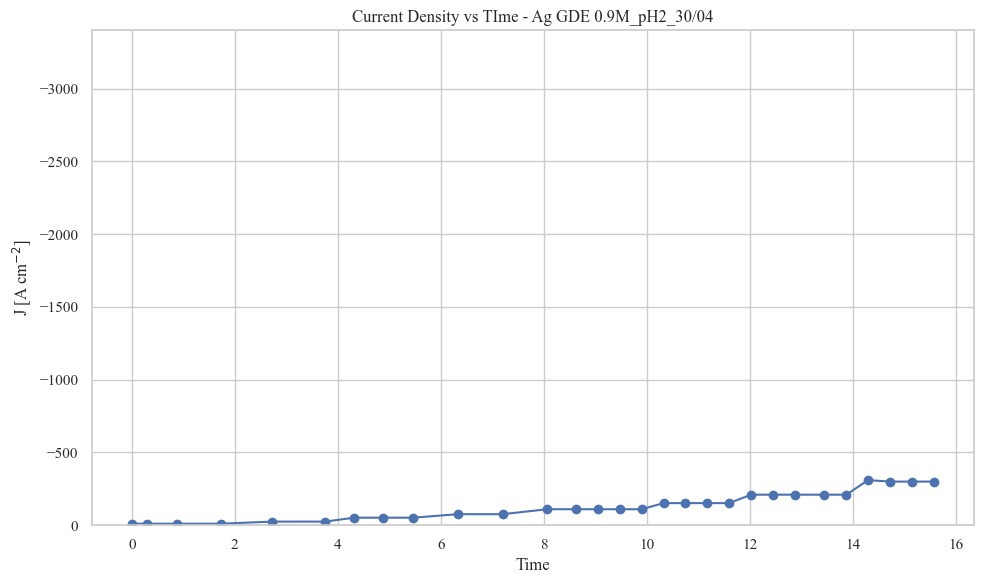

In [534]:
plt.figure(figsize=(10, 6)) 
plt.plot(Book["Duration / h"], Book['Current Density'], marker='o')  

plt.title('Current Density vs TIme - Ag GDE 0.9M_pH2_30/04')  
plt.xlabel('Time') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0,-3400)
# plt.gca().set_xticklabels([])
# plt.xticks([])
plt.tight_layout()

plt.show()

## Current Density vs Flow Rate

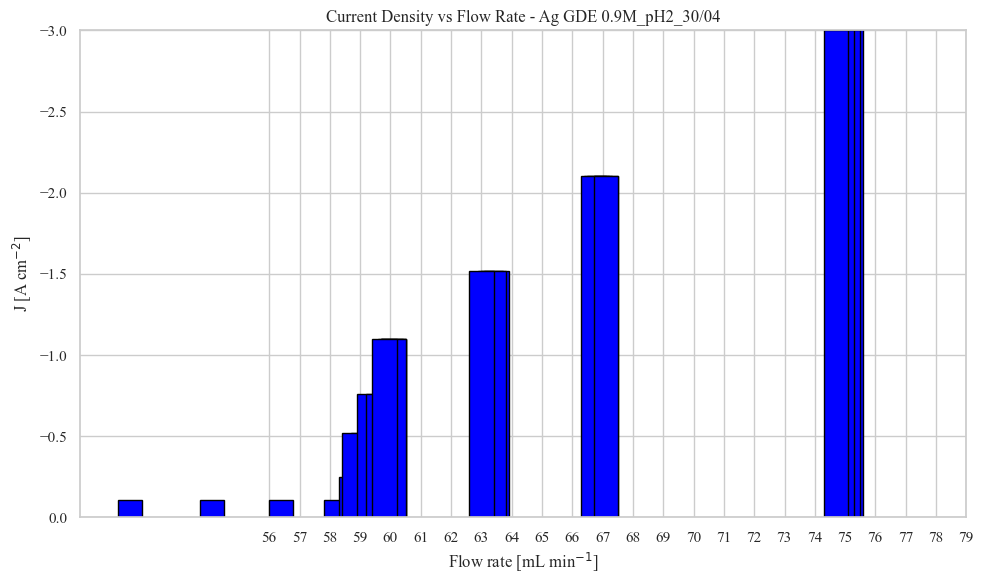

In [535]:
plt.figure(figsize=(10, 6)) 
plt.bar(Book["Flow rate (ml min-1)"], Book['Applied current / A'], color='blue', edgecolor='black')
plt.title('Current Density vs Flow Rate - Ag GDE 0.9M_pH2_30/04')  
plt.xlabel(r'Flow rate [mL min$^{-1}$]') 
plt.ylabel(r'J [A cm$^{-2}$]') #Latex
plt.grid(True)
plt.ylim(0, -3)
# plt.gca().set_xticklabels([])
plt.xticks(range(56,80,1))
plt.tight_layout()

plt.show()

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


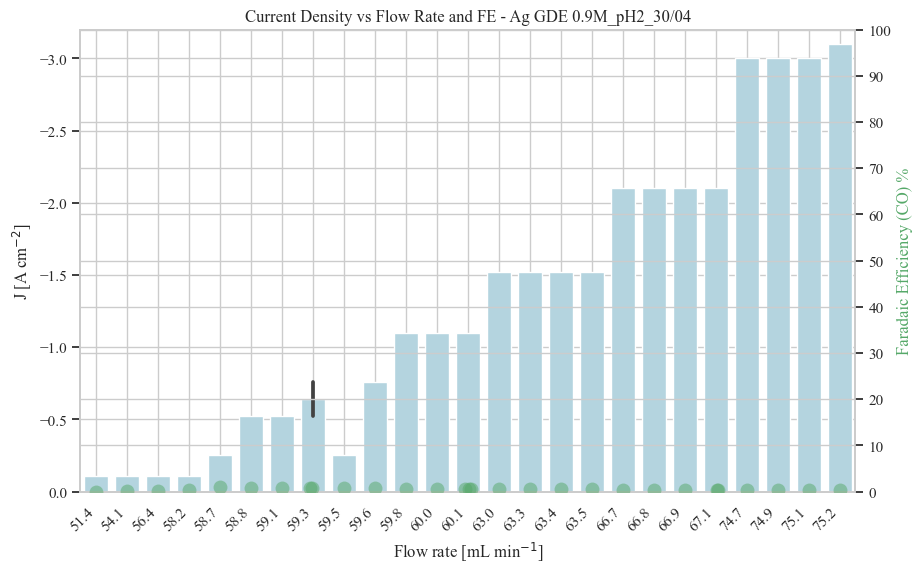

In [536]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis

sns.barplot(data=Book, x='Flow rate (ml min-1)', y='Applied current / A', ax=ax1, color='lightblue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Flow Rate and FE - Ag GDE 0.9M_pH2_30/04')
ax1.set_xlabel(r'Flow rate [mL min$^{-1}$]')
ax1.set_ylabel(r'J [A cm$^{-2}$]')
ax1.set_ylim(0, -3.2)
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=Book, x='Flow rate (ml min-1)',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=.5, legend=False, color='g')

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color='g')
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))

# plt.savefig('20240429_Ag_GDE_0_6M_pH2_29-04_CD_FL_FE_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [537]:
# g = sns.JointGrid(data=Book, x='Flow rate (ml min-1)',  y='Applied current / A', hue = 'FE(CO)')
# g.plot(sns.histplot, sns.kdeplot)

In [538]:
ls

 Volume in drive C is Windows
 Volume Serial Number is F86E-9ECB

 Directory of C:\Users\GOVEAALP\OneDrive - VITO\Documents\Experiments\2024\20240430 - Ag60 GDE_0.9 M Na2SO4_pH2

11-Aug-26  08:25 AM    <DIR>          .
10-Aug-26  10:21 AM    <DIR>          ..
10-Aug-26  06:30 PM    <DIR>          .ipynb_checkpoints
02-May-24  10:29 AM            77,896 0p9M_pH2 Na2SO4_20240502_0829_1min - Copy.xlsx
10-Aug-26  03:55 PM           105,456 0p9M_pH2 Na2SO4_20240502_0829_1min.xlsx
02-May-24  10:29 AM           613,118 0p9M_pH2 Na2SO4_20240502_0829_Line_1.csv
18-Jun-24  02:47 PM           755,772 20240430 - Ag60 GDE_0.9 M Na2SO4_pH2.ipynb
11-Aug-26  08:25 AM           752,821 20240430 - Ag60 GDE_0.9 M Na2SO4_pH2-CORRECTED.ipynb
11-Aug-26  08:26 AM               579 20240430_0.9 M Na2SO4_pH2_Energy Consumption.csv
11-Aug-26  07:28 AM             5,570 20240430_0.9M Na2SO4_pH2.csv
11-Aug-26  08:26 AM             1,410 20240430_0.9M Na2SO4_pH2_flow rate.csv
18-Jun-24  02:47 PM           150,946 

## Current Density vs Duration (h)

C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\GOVEAALP\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


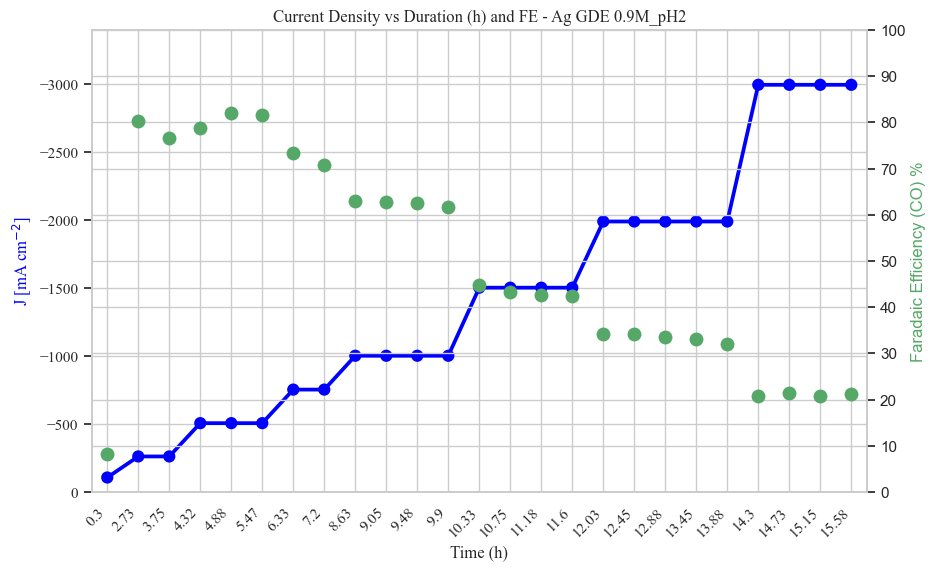

In [539]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barplot for 'Applied current / A' on the left y-axis
sns.set(style="whitegrid")
sns.pointplot(data=rows, x='Duration / h', y='Current Density', ax=ax1, color='blue')

# Set the title and labels for the barplot
ax1.set_title('Current Density vs Duration (h) and FE - Ag GDE 0.9M_pH2')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel(r'J [mA cm$^{-2}$]', color='blue')
ax1.set_ylim(0, -3400)
ax1.set_yticks(np.arange(0, -3400, -500))
ax1.grid(True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Secondary right y-axis
ax2 = ax1.twinx()
sns.stripplot(data=rows, x='Duration / h',  y='FE(CO)', ax=ax2, size=10, dodge=True, alpha=1, legend=False, color = "g")

# Set the label and limits for the secondary y-axis
ax2.set_ylabel('Faradaic Efficiency (CO) %', color = "g")
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 101, 10))
# ax2.set_xticks(np.arange(0, 18, 1))
# ax2.set_xticklabels(np.arange(0, 18, 1))

# plt.savefig('20240508_Ag_GDE_0_3M_pH1_CD_Durat_FE_lineplot.png', dpi=300, bbox_inches='tight')
plt.show()

#### Drop points from initial step in each current

In [540]:
rows = rows.drop(rows[rows['Duration / h'] == 0.0].index)
rows = rows.drop(rows[rows['Duration / h'] == 8.07].index)
rows

,Electrode,Inlet flow rate,Flow rate (ml min-1),Catholyte,Anolyte,Membrane,Applied current / A,Time,Duration / h,area(H2),...,GC_flow_rate_ml_min,Integer Duration,Current Density,Current_abs,Current [A],Flow_rate_mean_dry,Flow_rate_min_dry,Flow_rate_max_dry,Flow_rate_median_dry,FE(total)
1,Ag60 GDE in PTFE holder,60,54.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.107,2024-04-30 11:55:00,0.30,1.463835,...,54.1,0.0,-107.0,0.107,0.107,51.770208,49.860707,52.869699,51.849776,99.128209
4,Ag60 GDE in PTFE holder,60,58.7,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.262,2024-04-30 14:21:00,2.73,0.669595,...,58.7,2.0,-262.0,0.250,0.262,55.455947,52.661074,57.079735,55.865424,98.624299
5,Ag60 GDE in PTFE holder,60,59.5,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.262,2024-04-30 15:22:00,3.75,0.789326,...,59.5,3.0,-262.0,0.250,0.262,55.455947,52.661074,57.079735,55.865424,98.224714
6,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 15:56:00,4.32,0.689069,...,59.3,4.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,88.761010
7,Ag60 GDE in PTFE holder,60,59.1,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 16:30:00,4.88,0.742768,...,59.1,4.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,92.809610
8,Ag60 GDE in PTFE holder,60,58.8,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.507,2024-04-30 17:05:00,5.47,0.779967,...,58.8,5.0,-507.0,0.520,0.507,57.149625,56.269924,57.75734,57.114284,92.792664
9,Ag60 GDE in PTFE holder,60,59.3,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.754,2024-04-30 17:57:00,6.33,1.427604,...,59.3,6.0,-754.0,0.760,0.754,57.3867,56.93413,57.918866,57.360512,87.268020
10,Ag60 GDE in PTFE holder,60,59.6,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-0.754,2024-04-30 18:49:00,7.20,1.776337,...,59.6,7.0,-754.0,0.760,0.754,57.3867,56.93413,57.918866,57.360512,88.182106
11,Ag60 GDE in PTFE holder,60,59.8,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-1.003,2024-04-30 21:31:00,9.90,3.049153,...,59.8,9.0,-1003.0,1.100,1.003,57.868086,57.195466,58.852893,57.819952,84.350257
12,Ag60 GDE in PTFE holder,60,60.0,0.3 M Na2SO4,0.05 M H2SO4,CCM-CEM,-1.003,2024-04-30 20:40:00,9.05,2.921810,...,60.0,9.0,-1003.0,1.100,1.003,57.868086,57.195466,58.852893,57.819952,84.354522


## Current Density vs FE(CO)

## Stacked bar plot

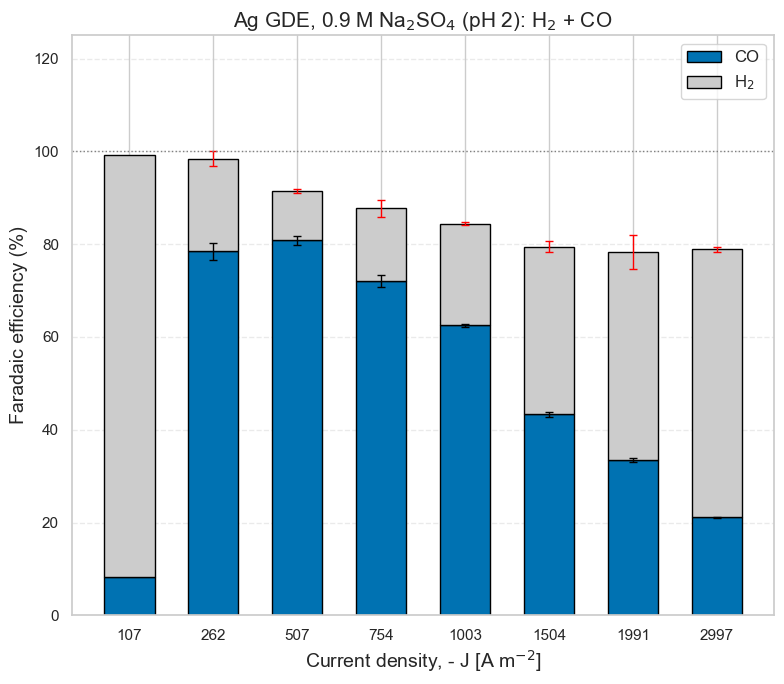

In [541]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_mean"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_mean"], w,
       bottom=summary["FE_CO_mean"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (bottom segment)
ax.errorbar(x, summary["FE_CO_mean"],
            yerr=summary["FE_CO_sem"],
            fmt="none", ecolor="black", capsize=3, lw=1)

# Error bars for H2 (top segment → must be shifted by CO)
ax.errorbar(x, summary["FE_CO_mean"] + summary["FE_H2_mean"],
            yerr=summary["FE_H2_sem"],
            fmt="none", ecolor="red", capsize=3, lw=1)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M Na$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_mean"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Median

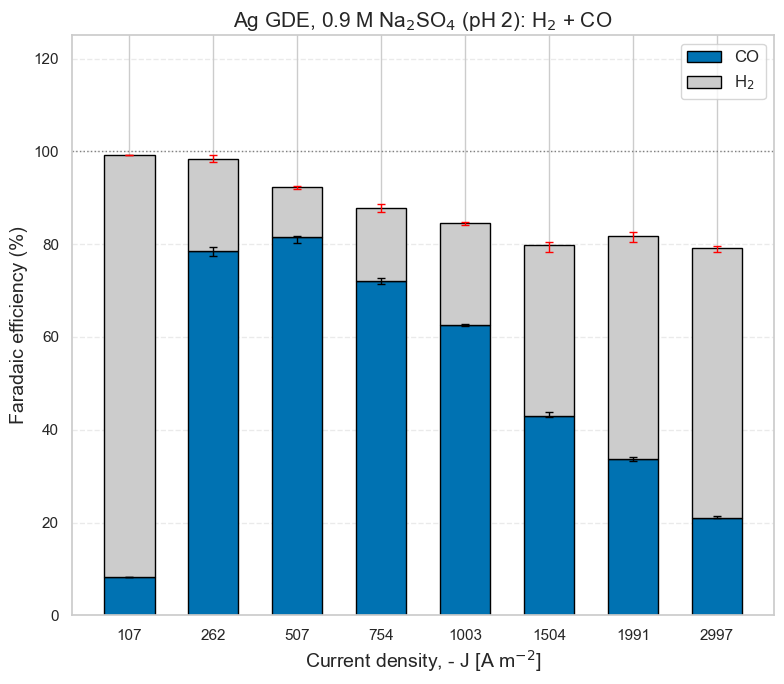

In [544]:
color_H2 = "#CCCCCC"
color_CO = "#0072B2"

fig, ax = plt.subplots(figsize=(8, 7))
x = np.arange(len(summary))
w = 0.6

# CO bottom
ax.bar(x, summary["FE_CO_median"], w,
       color=color_CO, edgecolor="black", lw=1, label="CO")

# H2 stacked on CO
ax.bar(x, summary["FE_H2_median"], w,
       bottom=summary["FE_CO_median"],
       color=color_H2, edgecolor="black", lw=1, label=r"H$_2$")

# Error bars for CO (median + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"],
    yerr=[
        summary["FE_CO_err_low"],
        summary["FE_CO_err_high"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    lw=1
)

# Error bars for H2 (shifted by CO + IQR)
ax.errorbar(
    x,
    summary["FE_CO_median"] + summary["FE_H2_median"],
    yerr=[
        summary["FE_H2_err_low"],
        summary["FE_H2_err_high"]
    ],
    fmt="none",
    ecolor="red",
    capsize=3,
    lw=1
)

ax.axhline(100, ls=":", color="grey", lw=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["J (A m-2)"])

ax.set_xlabel(r"Current density, - J [A m$^{-2}$]", fontsize=14)
ax.set_ylabel("Faradaic efficiency (%)", fontsize=14)
ax.set_title(r"Ag GDE, 0.9 M Na$_2$SO$_4$ (pH 2): H$_2$ + CO", fontsize=15)

ax.set_ylim(0, max(125, summary["FE_total_median"].max()*1.05))

ax.grid(axis="y", ls="--", alpha=0.4)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
# plt.savefig("FE_H2_CO_stacked_median_IQR.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean and Standard Deviation Applied Current and FE(CO)

In [545]:
standard_current_density = [
    100, 250, 500, 750,
    1000, 1500, 2000, 3000
]
summary["J (A m-2)_ps"] = summary["J (A m-2)"]
summary["J (A m-2)"] = standard_current_density #This is to have the same basis for later compare different experiments

In [546]:
Res_Book = summary.copy()

Res_Book = Res_Book.fillna(0)

Res_Book = Res_Book.rename(columns={
    # Mean
    "FE_H2_mean": "FE(H2)_mean",
    "FE_CO_mean": "FE(CO)_mean",
    "FE_total_mean": "FE(total)_mean",

    # Median
    "FE_H2_median": "FE(H2)_median",
    "FE_CO_median": "FE(CO)_median",
    "FE_total_median": "FE(total)_median",

    # Median error
    "FE_H2_q25": "FE(H2)_q25",
    "FE_H2_q75": "FE(H2)_q75",
    "FE_H2_err_low": "FE(H2)_err_low",
    "FE_H2_err_high": "FE(H2)_err_high",

    "FE_CO_q25": "FE(CO)_q25",
    "FE_CO_q75": "FE(CO)_q75",
    "FE_CO_err_low": "FE(CO)_err_low",
    "FE_CO_err_high": "FE(CO)_err_high",

    "FE_total_q25": "FE(total)_q25",
    "FE_total_q75": "FE(total)_q75",
    "FE_total_err_low": "FE(total)_err_low",
    "FE_total_err_high": "FE(total)_err_high",

    # SEM
    "FE_H2_sem": "FE(H2)_sem",
    "FE_CO_sem": "FE(CO)_sem",
    "FE_total_sem": "FE(total)_sem",

    # Standard deviation
    "FE_H2_std": "FE(H2)_std",
    "FE_CO_std": "FE(CO)_std",
    "FE_total_std": "FE(total)_std",

    # Current density
    "Current Density [A/m2]": "Current Density_mean"
})

Res_Book

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,90.900776,8.227432,90.900776,8.227432,0.000000,0.000000,0.000000,0.000000,90.900776,...,0.014221,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0–2,107
1,250,19.974374,78.450132,19.974374,78.450132,1.654137,1.853930,2.339303,2.621853,19.147305,...,0.007102,2,0.827069,0.827069,0.926965,0.926965,0.099896,0.099896,2–4,262
2,500,10.623867,80.830561,10.700402,81.546922,0.383050,1.010624,0.663462,1.750453,10.312929,...,0.007201,3,0.387472,0.272670,1.355685,0.281143,2.015827,0.008473,4–6,507
3,750,15.657252,72.067811,15.657252,72.067811,1.792506,1.335464,2.534987,1.888631,14.760998,...,0.015603,2,0.896253,0.896253,0.667732,0.667732,0.228521,0.228521,6–8,754
4,1000,21.886203,62.478351,21.864749,62.601593,0.300298,0.263463,0.600597,0.526927,21.525921,...,0.028754,4,0.338828,0.360282,0.305439,0.182197,0.045877,0.058042,8–10,1003
5,1500,36.075511,43.369335,36.779185,43.042665,1.154308,0.523279,2.308615,1.046558,35.350410,...,0.071791,4,1.428775,0.725101,0.356317,0.682987,0.745789,0.368785,10–12,1504
6,2000,44.904743,33.431299,48.132619,33.614692,3.669808,0.407874,8.205940,0.912033,46.867974,...,0.118138,5,1.264646,0.868496,0.408331,0.563978,0.697473,0.367049,12–14,1991
7,3000,57.781385,21.107219,58.072005,21.076218,0.545567,0.150171,1.091133,0.300342,57.237152,...,0.203341,4,0.834854,0.544233,0.200515,0.231516,0.677548,0.337151,14–16,2997


In [549]:
# Res_Book = Res_Book.drop(Res_Book[Res_Book['Current Density_mean'] == -10.0].index)
Res_Book
# Res_Book.to_csv('20240430_0.9M Na2SO4_pH2.csv')

,J (A m-2),FE(H2)_mean,FE(CO)_mean,FE(H2)_median,FE(CO)_median,FE(H2)_sem,FE(CO)_sem,FE(H2)_std,FE(CO)_std,FE(H2)_q25,...,c_H2_median,n,FE(H2)_err_low,FE(H2)_err_high,FE(CO)_err_low,FE(CO)_err_high,FE(total)_err_low,FE(total)_err_high,Time Interval (h),J (A m-2)_ps
0,100,90.900776,8.227432,90.900776,8.227432,0.000000,0.000000,0.000000,0.000000,90.900776,...,0.014221,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0–2,107
1,250,19.974374,78.450132,19.974374,78.450132,1.654137,1.853930,2.339303,2.621853,19.147305,...,0.007102,2,0.827069,0.827069,0.926965,0.926965,0.099896,0.099896,2–4,262
2,500,10.623867,80.830561,10.700402,81.546922,0.383050,1.010624,0.663462,1.750453,10.312929,...,0.007201,3,0.387472,0.272670,1.355685,0.281143,2.015827,0.008473,4–6,507
3,750,15.657252,72.067811,15.657252,72.067811,1.792506,1.335464,2.534987,1.888631,14.760998,...,0.015603,2,0.896253,0.896253,0.667732,0.667732,0.228521,0.228521,6–8,754
4,1000,21.886203,62.478351,21.864749,62.601593,0.300298,0.263463,0.600597,0.526927,21.525921,...,0.028754,4,0.338828,0.360282,0.305439,0.182197,0.045877,0.058042,8–10,1003
5,1500,36.075511,43.369335,36.779185,43.042665,1.154308,0.523279,2.308615,1.046558,35.350410,...,0.071791,4,1.428775,0.725101,0.356317,0.682987,0.745789,0.368785,10–12,1504
6,2000,44.904743,33.431299,48.132619,33.614692,3.669808,0.407874,8.205940,0.912033,46.867974,...,0.118138,5,1.264646,0.868496,0.408331,0.563978,0.697473,0.367049,12–14,1991
7,3000,57.781385,21.107219,58.072005,21.076218,0.545567,0.150171,1.091133,0.300342,57.237152,...,0.203341,4,0.834854,0.544233,0.200515,0.231516,0.677548,0.337151,14–16,2997


## Mean and StD of FE(CO) through time

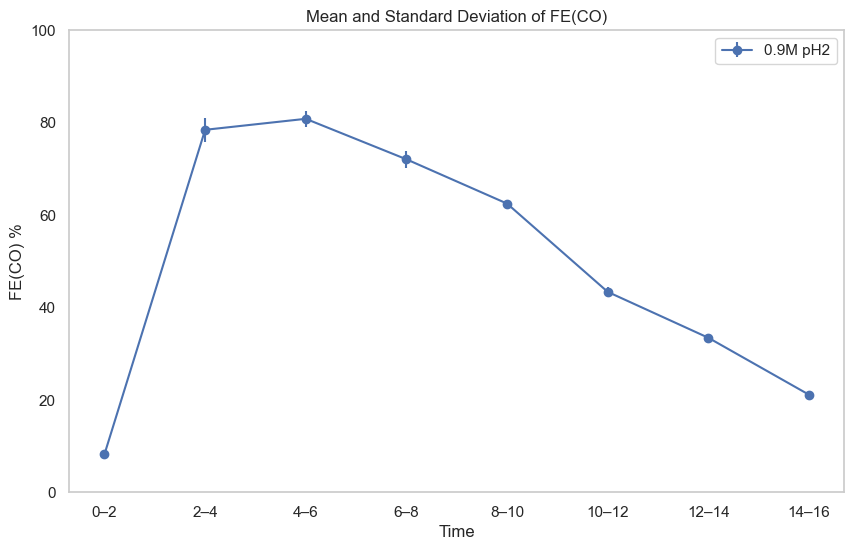

In [550]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Applied Current mean with standard deviation
# ax.errorbar(resampled_df.index, resampled_df['Applied current / A_mean'], 
#             yerr=resampled_df['Applied current / A_std'], fmt='-o', label='Applied current / A_mean')

# Plot FE (CO) mean with standard deviation
ax.errorbar(Res_Book["Time Interval (h)"], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.9M pH2')

# Formatting the plot
ax.set_xlabel('Time')
ax.set_ylabel('FE(CO) %')
ax.set_title('Mean and Standard Deviation of FE(CO)')
ax.set_ylim(0,100)
ax.legend()
ax.grid(False)

# plt.savefig('20240430_0.9M_pH2_mean_std_time.png', dpi=300, bbox_inches='tight')
plt.show()

## Current Density vs FE(CO)_ mean and std

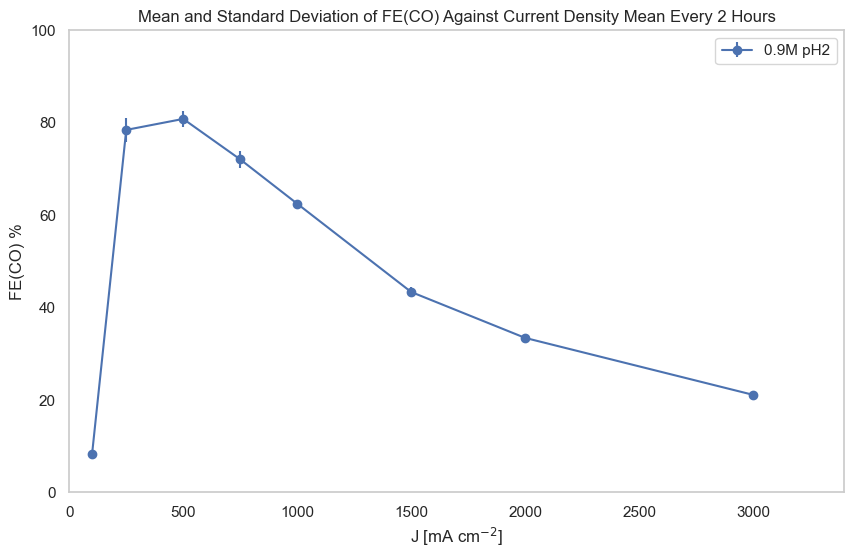

In [551]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot FE (CO) mean with standard deviation against Applied Current mean
ax.errorbar(Res_Book['J (A m-2)'], Res_Book['FE(CO)_mean'], 
            yerr=Res_Book['FE(CO)_std'], fmt='-o', label='0.9M pH2')

# Formatting the plot
ax.set_xlabel(r'J [mA cm$^{-2}$]')
ax.set_ylabel('FE(CO) %')
ax.set_xlim(0,3400)
ax.set_ylim(0,100)
ax.set_title('Mean and Standard Deviation of FE(CO) Against Current Density Mean Every 2 Hours')
ax.legend()
ax.grid(False)

# plt.savefig('20240430_0.9M_pH2_mean_std_FE(CO)vsCD.png', dpi=300, bbox_inches='tight')
plt.show()